## **Phase 2: Machine Learning Benchmark & The Resolution Ceiling**

In data-scarce urban catchments, physical models often struggle to capture non-linear hydrological realities. This phase evaluates whether pure Deep Learning can accurately forecast peak flash flood events using continuous daily satellite meteorology. 

#### **Scientific Methodology & Feature Engineering**

To ensure the model captures the physical realities of the West African climate and the Eleyele catchment, the following techniques were explicitly engineered into the architecture:

* **Cyclical Seasonality (`Sin_Season`, `Cos_Season`):** To capture the distinct wet and dry season dynamics, temporal variables were transformed into continuous cyclical features using Sine and Cosine encodings, preventing boundary discontinuities at the turn of the calendar year.
* **Autoregressive Memory (`Q_lag1` to `Q_lag7`):** Hydrological systems exhibit significant physical inertia. Autoregressive features (1-to-7 day lagged discharge) were integrated to explicitly provide the model with the catchment's immediate baseflow condition and recession limb dynamics.
* **14-Day Lookback Window:** A 14-day sequence lookback was established to encompass the typical duration of tropical synoptic weather systems and the corresponding soil moisture saturation periods prior to a flood event.

#### **Model Architecture: Encoder-Decoder Attention-LSTM**

Standard recurrent networks often suffer from information degradation over long sequences. An Encoder-Decoder architecture equipped with a Cross-Attention mechanism was deployed. 

* **The Attention Mechanism:** This allows the network to dynamically assign higher mathematical weight to specific antecedent days that act as critical runoff triggers, mirroring the variable time of concentration in physical catchments.
* **Huber Loss Optimization:** To ensure stable gradient descent in the presence of extreme hydro-meteorological outliers, a Huber Loss (`SmoothL1Loss`) function was utilized, preventing anomalous flood peaks from disproportionately skewing the network weights.

#### **Explainable AI (XAI) & Objective**

To overcome the "black-box" critique of deep learning in water resources, **SHapley Additive exPlanations (SHAP)** were integrated to provide global model interpretability, verifying that the network's predictive logic aligns with physical hydrological drivers.

**The Objective:** This phase empirically tests the predictive limits of the data. The results demonstrate a "resolution ceiling," proving that while the Attention-LSTM captures broad temporal patterns, daily aggregated rainfall mathematically smooths out the sub-hourly intensity required to predict urban flash floods. This finding explicitly justifies the transition to the System Dynamics physical scenario testing in Phase 3.

Success! Figure 2 saved in high resolution (300 dpi) at: EDA/Figure_2_Seasonality.png


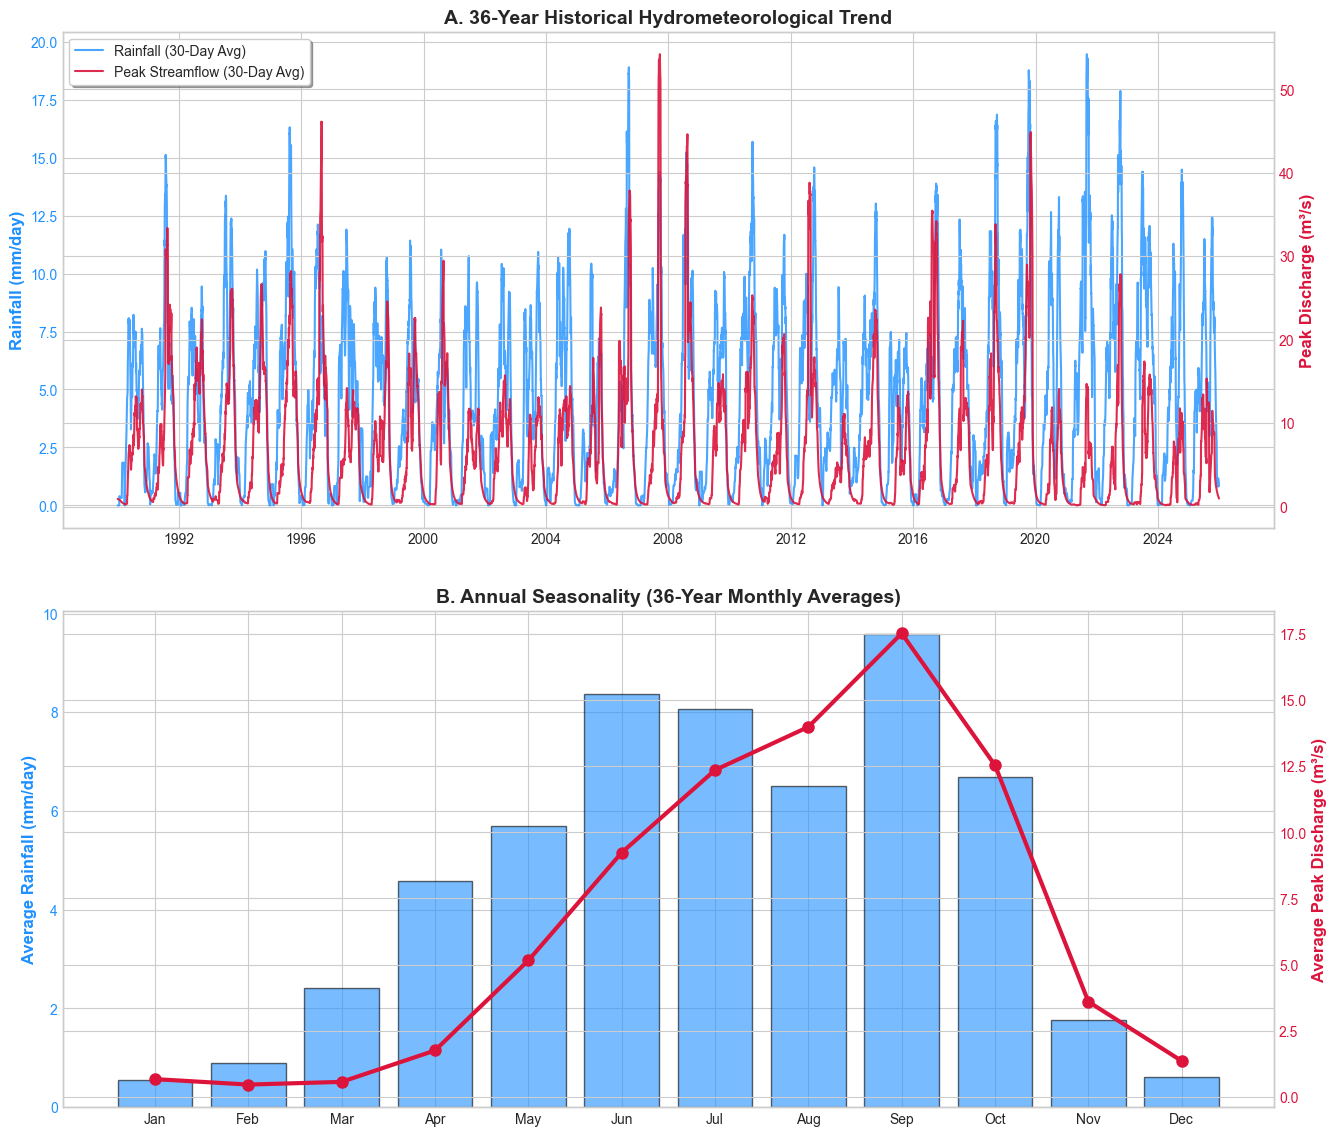

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Create a folder for EDA if it doesn't exist
os.makedirs('EDA', exist_ok=True)

# 1. Load the Master Dataset
df = pd.read_csv('Eleyele_HydroMet_Master.csv')

# Ensure Date is the index
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)
else:
    # Fallback if the index is already datetime but unnamed
    df.index = pd.to_datetime(df.index)

# Define column names based on your master dataset
rain_col = 'PRECTOTCORR'
flow_col = 'Q_peak_m3s' 

# 2. Setup the Matplotlib Canvas
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

# =====================================================================
# PANEL A: Full 36-Year Timeseries (30-Day Rolling Average for clarity)
# =====================================================================
# Apply a 30-day moving average to smooth out the daily noise
rain_roll = df[rain_col].rolling(window=30, min_periods=1).mean()
flow_roll = df[flow_col].rolling(window=30, min_periods=1).mean()

# Plot Rainfall on primary Y-axis (inverted to look like falling rain, a standard in hydrology)
ax1.plot(df.index, rain_roll, color='dodgerblue', alpha=0.8, linewidth=1.5, label='Rainfall (30-Day Avg)')
ax1.set_ylabel('Rainfall (mm/day)', color='dodgerblue', fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='dodgerblue')

# Plot Streamflow on secondary Y-axis
ax1_twin = ax1.twinx()
ax1_twin.plot(df.index, flow_roll, color='crimson', alpha=0.9, linewidth=1.5, label='Peak Streamflow (30-Day Avg)')
ax1_twin.set_ylabel('Peak Discharge (m³/s)', color='crimson', fontsize=12, fontweight='bold')
ax1_twin.tick_params(axis='y', labelcolor='crimson')

ax1.set_title('A. 36-Year Historical Hydrometeorological Trend', fontsize=14, fontweight='bold')

# Combine legends for Panel A
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax1_twin.get_legend_handles_labels()
ax1_twin.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', frameon=True, shadow=True)

# =====================================================================
# PANEL B: Hydrological Seasonality (Average Monthly Climatology)
# =====================================================================
# Group by month across the entire 36 years to get the seasonal pattern
monthly_avg = df.groupby(df.index.month)[[rain_col, flow_col]].mean()
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Plot Average Rainfall as bars
ax2.bar(months, monthly_avg[rain_col], color='dodgerblue', alpha=0.6, edgecolor='black')
ax2.set_ylabel('Average Rainfall (mm/day)', color='dodgerblue', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='dodgerblue')

# Plot Average Streamflow as a line over the bars
ax2_twin = ax2.twinx()
ax2_twin.plot(months, monthly_avg[flow_col], color='crimson', marker='o', markersize=8, linewidth=3, label='Average Peak Streamflow')
ax2_twin.set_ylabel('Average Peak Discharge (m³/s)', color='crimson', fontsize=12, fontweight='bold')
ax2_twin.tick_params(axis='y', labelcolor='crimson')

ax2.set_title('B. Annual Seasonality (36-Year Monthly Averages)', fontsize=14, fontweight='bold')

# =====================================================================
# Final Polish and Export
# =====================================================================
plt.tight_layout(pad=3.0)
output_path = 'EDA/Figure_2_Seasonality.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Success! Figure 2 saved in high resolution (300 dpi) at: {output_path}")

plt.show()

In [6]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import shap
import copy
import os

# Fix seeds for academic reproducibility
np.random.seed(42)
torch.manual_seed(42)
os.makedirs('Hydrological', exist_ok=True)

print("--- Step 1: Loading & Engineering Features ---")
df = pd.read_csv('Eleyele_HydroMet_Master.csv')

df['Date'] = pd.to_datetime(df['Date'] if 'Date' in df.columns else df.index)
df['DayOfYear'] = df['Date'].dt.dayofyear
df['Sin_Season'] = np.sin(2 * np.pi * df['DayOfYear'] / 365.25)
df['Cos_Season'] = np.cos(2 * np.pi * df['DayOfYear'] / 365.25)

for i in range(1, 8):
    df[f'Q_lag{i}'] = df['Q_peak_m3s'].shift(i)
df = df.dropna().reset_index(drop=True)

feature_cols = [
    'PRECTOTCORR', 'T2M_MAX', 'T2M_MIN', 'ALLSKY_SFC_SW_DWN',
    'Rain_3Day_Roll', 'Rain_7Day_Roll', 'Sin_Season', 'Cos_Season',
    'Q_lag1', 'Q_lag2', 'Q_lag3', 'Q_lag4', 'Q_lag5', 'Q_lag6', 'Q_lag7',
]

target_col = ['Q_peak_m3s']
LOOKBACK = 14
FORECAST = 1

def create_sequences(X, y, lookback, forecast):
    X_seq, y_seq = [], []
    for i in range(len(X) - lookback - forecast + 1):
        X_seq.append(X[i: i + lookback])
        y_seq.append(y[i + lookback: i + lookback + forecast])
    return np.array(X_seq), np.array(y_seq)

n = len(df)
train_end = int(n * 0.70)
val_end = int(n * 0.80)

scaler_x = StandardScaler().fit(df[feature_cols].iloc[:train_end])
X_scaled = scaler_x.transform(df[feature_cols])
y_real = df[target_col].values 

X_seq, y_seq = create_sequences(X_scaled, y_real, LOOKBACK, FORECAST)
seq_train_end = max(1, train_end - LOOKBACK)
seq_val_end = max(seq_train_end + 1, val_end - LOOKBACK)

X_train, y_train = X_seq[:seq_train_end], y_seq[:seq_train_end]
X_val, y_val = X_seq[seq_train_end:seq_val_end], y_seq[seq_train_end:seq_val_end]
X_test, y_test = X_seq[seq_val_end:], y_seq[seq_val_end:]
actual_real = y_test.flatten()

# =====================================================================
# --- Step 2: Model Architecture ---
# =====================================================================
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=num_layers, batch_first=True, dropout=0.2)
    def forward(self, x):
        outputs, (hidden, cell) = self.lstm(x)
        return outputs, hidden, cell

class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim * 2, hidden_dim)
        self.v = nn.Parameter(torch.rand(hidden_dim))
    def forward(self, hidden, encoder_outputs):
        hidden = hidden[-1]
        seq_len = encoder_outputs.shape[1]
        hidden_repeated = hidden.unsqueeze(1).repeat(1, seq_len, 1)
        energy = torch.tanh(self.attn(torch.cat((hidden_repeated, encoder_outputs), dim=2)))
        energy = energy.transpose(1, 2)
        v = self.v.repeat(encoder_outputs.shape[0], 1).unsqueeze(1)
        attention_scores = torch.bmm(v, energy).squeeze(1)
        return F.softmax(attention_scores, dim=1)

class Decoder(nn.Module):
    def __init__(self, output_dim, hidden_dim, num_layers=2):
        super().__init__()
        self.attention = Attention(hidden_dim)
        self.lstm = nn.LSTM(output_dim + hidden_dim, hidden_dim, num_layers=num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
    def forward(self, x, hidden, cell, encoder_outputs):
        a = self.attention(hidden, encoder_outputs).unsqueeze(1)
        context = torch.bmm(a, encoder_outputs)
        lstm_input = torch.cat((x, context), dim=2)
        output, (hidden, cell) = self.lstm(lstm_input, (hidden, cell))
        prediction = self.fc(torch.cat((output.squeeze(1), context.squeeze(1)), dim=1))
        return prediction.unsqueeze(1), hidden, cell

class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
    def forward(self, source, target_len=1):
        batch_size = source.shape[0]
        encoder_outputs, hidden, cell = self.encoder(source)
        decoder_input = torch.zeros(batch_size, 1, 1).to(source.device)
        outputs = []
        for t in range(target_len):
            out, hidden, cell = self.decoder(decoder_input, hidden, cell, encoder_outputs)
            outputs.append(out)
            decoder_input = out
        return torch.cat(outputs, dim=1)

hidden_size = 128
encoder = Encoder(input_dim=len(feature_cols), hidden_dim=hidden_size, num_layers=2)
decoder = Decoder(output_dim=1, hidden_dim=hidden_size, num_layers=2)
lstm_model = Seq2SeqAttention(encoder, decoder)

criterion = nn.SmoothL1Loss() 
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.001, weight_decay=1e-5)

train_loader = DataLoader(TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32)), batch_size=128, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.float32)), batch_size=128, shuffle=False)

# =====================================================================
# --- Step 3: Training ---
# =====================================================================
print("\n--- Step 3: Training Encoder-Decoder Attention-LSTM ---")
EPOCHS = 60
best_val_loss = float('inf')
patience = 12
patience_counter = 0
best_model_weights = None

for epoch in range(1, EPOCHS + 1):
    lstm_model.train()
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = lstm_model(X_batch, target_len=FORECAST)
        loss = criterion(output, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(lstm_model.parameters(), max_norm=1.0)
        optimizer.step()

    lstm_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            output = lstm_model(X_batch, target_len=FORECAST)
            val_loss += criterion(output, y_batch).item()
    val_loss /= len(val_loader)

    if epoch % 5 == 0 or epoch == 1:
        print(f"  Epoch {epoch:02d}/{EPOCHS} | Val Loss: {val_loss:.5f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_weights = copy.deepcopy(lstm_model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"  Early stopping at epoch {epoch}.")
        break

lstm_model.load_state_dict(best_model_weights)
lstm_model.eval()

with torch.no_grad():
    lstm_preds = lstm_model(torch.tensor(X_test, dtype=torch.float32), target_len=FORECAST).squeeze(-1).numpy().flatten()
    lstm_preds = np.maximum(lstm_preds, 0) # No negative flows

# =====================================================================
# --- Step 4: Publication Visualizations (Hydrograph) ---
# =====================================================================
print("\n--- Step 4: Generating Visualizations ---")
plt.style.use('seaborn-v0_8-whitegrid')
days_to_plot = min(365, len(actual_real))

plt.figure(figsize=(12, 5))
plt.plot(actual_real[-days_to_plot:], label='Observed Peak Flow (m³/s)', color='black', linewidth=1.5)
plt.plot(lstm_preds[-days_to_plot:], label='LSTM Prediction (m³/s)', color='crimson', linestyle='--', linewidth=1.5)
plt.title(f'Temporal Flood Hydrograph (Final 1-Year Test Set)', fontsize=14, fontweight='bold')
plt.xlabel('Time (Days)', fontsize=12, fontweight='bold')
plt.ylabel('Peak Discharge (m³/s)', fontsize=12, fontweight='bold')
plt.legend(frameon=True, shadow=True)
plt.tight_layout()
plt.savefig('Hydrological/Final_Hydrograph_LSTM.png', dpi=300)
plt.close()
print("Saved Hydrograph: Hydrological/Final_Hydrograph_LSTM.png")

# =====================================================================
# --- Step 5: SHAP Explainable AI (THE FLATTEN METHOD) ---
# =====================================================================
print("\n--- Step 5: Running SHAP Analysis (Explainable AI) ---")

# SHAP needs a simple wrapper to bypass the 'target_len' argument
class SHAPWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        return self.model(x, target_len=1).squeeze(-1)

wrapped_model = SHAPWrapper(lstm_model)

# Use a small background dataset to prevent memory crash
background = torch.tensor(X_train[:150], dtype=torch.float32)
test_sample = torch.tensor(X_test[:150], dtype=torch.float32)

explainer = shap.GradientExplainer(wrapped_model, background)
raw_shap_values = explainer.shap_values(test_sample)

# THE BULLETPROOF FIX: 
# Convert whatever SHAP returned into a numpy array, then forcefully flatten 
# everything EXCEPT the 15 features into a single 2D matrix.
shaps_array = np.array(raw_shap_values)

# Reshape both SHAP values and Test data to (N_samples * Lookback, 15_Features)
# This completely bypasses the axis confusion and gives SHAP the exact 2D shape it needs
num_features = len(feature_cols)
shap_values_2d = shaps_array.reshape(-1, num_features)
X_test_2d = test_sample.numpy().reshape(-1, num_features)


# --- Create clean names matching the exact order of your feature_cols ---
clean_feature_names = [
    'Daily Rainfall (mm)', 
    'Max Temperature (°C)', 
    'Min Temperature (°C)', 
    'Solar Radiation',
    '3-Day Antecedent Rain', 
    '7-Day Antecedent Rain', 
    'Seasonality (Sine)', 
    'Seasonality (Cosine)',
    'Streamflow (Lag 1-Day)', 
    'Streamflow (Lag 2-Day)', 
    'Streamflow (Lag 3-Day)', 
    'Streamflow (Lag 4-Day)', 
    'Streamflow (Lag 5-Day)', 
    'Streamflow (Lag 6-Day)', 
    'Streamflow (Lag 7-Day)'
]

# Generate the plot using the clean names
plt.figure(figsize=(10, 8)) # Slightly taller to fit the nice new labels
shap.summary_plot(shap_values_2d, features=X_test_2d, feature_names=clean_feature_names, show=False)

plt.title('SHAP Feature Importance (Attention-LSTM)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Hydrological/SHAP_Summary_Plot.png', dpi=300, bbox_inches='tight')
plt.close()

print("Saved CLEAN SHAP Explainability Plot: Hydrological/SHAP_Summary_Plot.png")
# Generate the plot


--- Step 1: Loading & Engineering Features ---

--- Step 3: Training Encoder-Decoder Attention-LSTM ---
  Epoch 01/60 | Val Loss: 5.00783
  Epoch 05/60 | Val Loss: 4.72623
  Epoch 10/60 | Val Loss: 4.73121
  Epoch 15/60 | Val Loss: 4.83768
  Early stopping at epoch 17.

--- Step 4: Generating Visualizations ---
Saved Hydrograph: Hydrological/Final_Hydrograph_LSTM.png

--- Step 5: Running SHAP Analysis (Explainable AI) ---


C:\Users\USER\AppData\Local\Temp\ipykernel_14344\824622706.py:254: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_2d, features=X_test_2d, feature_names=clean_feature_names, show=False)


Saved CLEAN SHAP Explainability Plot: Hydrological/SHAP_Summary_Plot.png


In [7]:
import numpy as np
from sklearn.metrics import mean_squared_error

# 1. Generate predictions for the TRAINING set
lstm_model.eval()
with torch.no_grad():
    train_preds = lstm_model(torch.tensor(X_train, dtype=torch.float32), target_len=FORECAST).squeeze(-1).numpy().flatten()
    train_preds = np.maximum(train_preds, 0) # No negative flows
    y_train_flat = y_train.flatten()

# 2. Define the Metric Functions
def calc_nse(obs, pred):
    return 1 - (np.sum((obs - pred)**2) / np.sum((obs - np.mean(obs))**2))

def calc_rmse(obs, pred):
    return np.sqrt(mean_squared_error(obs, pred))

def calc_pbias(obs, pred):
    # PBIAS formula: 100 * sum(obs - pred) / sum(obs)
    return 100 * (np.sum(obs - pred) / np.sum(obs))

def calc_peak_nse(obs, pred, top_percent=5):
    # Get the threshold for the top 5% of observed flows
    threshold = np.percentile(obs, 100 - top_percent)
    peak_indices = np.where(obs >= threshold)[0]
    return calc_nse(obs[peak_indices], pred[peak_indices])

# 3. Calculate and Print Metrics for the Table
print("--- TABLE 1 METRICS ---")
print(f"Training NSE:        {calc_nse(y_train_flat, train_preds):.3f}")
print(f"Test NSE:            {calc_nse(actual_real, lstm_preds):.3f}")
print("-" * 25)
print(f"Training RMSE:       {calc_rmse(y_train_flat, train_preds):.3f}")
print(f"Test RMSE:           {calc_rmse(actual_real, lstm_preds):.3f}")
print("-" * 25)
print(f"Training PBIAS (%):  {calc_pbias(y_train_flat, train_preds):.3f}")
print(f"Test PBIAS (%):      {calc_pbias(actual_real, lstm_preds):.3f}")
print("-" * 25)
print(f"Training Peak NSE:   {calc_peak_nse(y_train_flat, train_preds):.3f}")
print(f"Test Peak NSE:       {calc_peak_nse(actual_real, lstm_preds):.3f}")

--- TABLE 1 METRICS ---
Training NSE:        0.220
Test NSE:            0.201
-------------------------
Training RMSE:       13.033
Test RMSE:           12.317
-------------------------
Training PBIAS (%):  29.133
Test PBIAS (%):      11.632
-------------------------
Training Peak NSE:   -0.494
Test Peak NSE:       -0.587
